### Importación

In [1]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import time
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize, LabelEncoder, StandardScaler
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt

In [2]:
def cargar_datos(
    carpeta="images_training_rev1",
    archivo_clasificaciones="training_solutions_rev1.csv",
    max_imagenes=61578,
    crop_size=(64, 64),      # Recorte central
    resize_to=(32, 32)       # Redimensionar después de recortar
):
    df = pd.read_csv(archivo_clasificaciones)
    print(f"Archivo CSV cargado con {len(df)} filas.")

    if "GalaxyID" not in df.columns:
        raise ValueError("El archivo CSV debe tener una columna 'GalaxyID' que identifique las imágenes.")

    galaxy_ids = df["GalaxyID"].astype(str).tolist()
    archivos = [f for f in os.listdir(carpeta) if f.lower().endswith((".jpg", ".png", ".jpeg"))]
    archivos_validos = [f for f in archivos if f.split(".")[0] in galaxy_ids]

    if len(archivos_validos) > max_imagenes:
        archivos_validos = random.sample(archivos_validos, max_imagenes)

    print(f"Se seleccionaron {len(archivos_validos)} imágenes aleatorias.")

    X, y = [], []
    from tqdm import tqdm
    for nombre in tqdm(archivos_validos, desc="Cargando imágenes"):
        galaxy_id = nombre.split(".")[0]
        fila = df[df["GalaxyID"] == int(galaxy_id)].iloc[0]
        etiqueta = fila.drop("GalaxyID").idxmax()

        ruta = os.path.join(carpeta, nombre)
        try:
            img = Image.open(ruta).convert("RGB")
            w, h = img.size
            cw, ch = crop_size
            left = (w - cw) // 2
            top = (h - ch) // 2
            img_cropped = img.crop((left, top, left + cw, top + ch))
            img_resized = img_cropped.resize(resize_to)
            X.append(np.array(img_resized))
            y.append(etiqueta)
        except Exception as e:
            print(f"Error al cargar {nombre}: {e}")

    X = np.array(X)
    print(f"Se cargaron {len(X)} imágenes etiquetadas de '{carpeta}'.")
    return X, y

# Ejemplo de uso:
X, y = cargar_datos(
    carpeta="images_training_rev1",
    archivo_clasificaciones="training_solutions_rev1.csv",
    max_imagenes=61578,
    crop_size=(64, 64),      # Recorta a 64x64
    resize_to=(32, 32)       # Luego resize a 32x32
)

Archivo CSV cargado con 61578 filas.
Se seleccionaron 61578 imágenes aleatorias.


Cargando imágenes: 100%|██████████| 61578/61578 [00:59<00:00, 1029.20it/s]

Se cargaron 61578 imágenes etiquetadas de 'images_training_rev1'.


In [5]:
def cargar_mismas_imagenes(
    carpeta="images_training_rev1",
    archivo_clasificaciones="training_solutions_rev1.csv",
    max_imagenes=12000,
    size=(32, 32)
):
    # Leer CSV
    df = pd.read_csv(archivo_clasificaciones)
    if "GalaxyID" not in df.columns:
        raise ValueError("El archivo CSV debe tener una columna 'GalaxyID'.")
    galaxy_ids = df["GalaxyID"].astype(str).tolist()
    archivos = [f for f in os.listdir(carpeta) if f.lower().endswith((".jpg", ".png", ".jpeg"))]
    archivos_validos = [f for f in archivos if f.split(".")[0] in galaxy_ids]
    # Seleccionar una sola vez
    if len(archivos_validos) > max_imagenes:
        archivos_validos = random.sample(archivos_validos, max_imagenes)
    print(f"Se seleccionaron {len(archivos_validos)} imágenes para ambos conjuntos.")

    from tqdm import tqdm
    # Cargar en gris
    X_gray, y_gray = [], []
    for nombre in tqdm(archivos_validos, desc="Cargando imágenes en gris"):
        galaxy_id = nombre.split(".")[0]
        fila = df[df["GalaxyID"] == int(galaxy_id)].iloc[0]
        etiqueta = fila.drop("GalaxyID").idxmax()
        ruta = os.path.join(carpeta, nombre)
        try:
            img = Image.open(ruta).convert("L").resize(size)
            X_gray.append(np.array(img))
            y_gray.append(etiqueta)
        except Exception as e:
            print(f"Error al cargar {nombre} (gris): {e}")

    # Cargar en RGB
    X_rgb, y_rgb = [], []
    for nombre in tqdm(archivos_validos, desc="Cargando imágenes en RGB"):
        galaxy_id = nombre.split(".")[0]
        fila = df[df["GalaxyID"] == int(galaxy_id)].iloc[0]
        etiqueta = fila.drop("GalaxyID").idxmax()
        ruta = os.path.join(carpeta, nombre)
        try:
            img = Image.open(ruta).convert("RGB").resize(size)
            X_rgb.append(np.array(img))
            y_rgb.append(etiqueta)
        except Exception as e:
            print(f"Error al cargar {nombre} (RGB): {e}")

    X_gray = np.array(X_gray)
    X_rgb = np.array(X_rgb)
    print(f"Se cargaron {len(X_gray)} imágenes en gris y {len(X_rgb)} en RGB.")
    return X_gray, y_gray, X_rgb, y_rgb

# Uso:
X_gray, y_gray, X_rgb, y_rgb = cargar_mismas_imagenes(
    carpeta="images_training_rev1",
    max_imagenes=12000,
    archivo_clasificaciones="training_solutions_rev1.csv",
    size=(32, 32),
)

Se seleccionaron 12000 imágenes para ambos conjuntos.


Cargando imágenes en RGB: 100%|██████████| 12000/12000 [00:19<00:00, 602.51it/s]

Se cargaron 12000 imágenes en gris y 12000 en RGB.


In [6]:
# Filtrar clases con al menos 2 muestras para evitar errores en train_test_split (aplica a Gray y RGB)

from collections import Counter
import numpy as np

# Para escala de grises
conteos_gray = Counter(y_gray)
clases_validas_gray = [cl for cl, cnt in conteos_gray.items() if cnt > 1]
mask_gray = [y in clases_validas_gray for y in y_gray]
X_gray_filtrado = X_gray[np.array(mask_gray)]
y_gray_filtrado = [y for y in y_gray if y in clases_validas_gray]

# Para RGB
conteos_rgb = Counter(y_rgb)
clases_validas_rgb = [cl for cl, cnt in conteos_rgb.items() if cnt > 1]
mask_rgb = [y in clases_validas_rgb for y in y_rgb]
X_rgb_filtrado = X_rgb[np.array(mask_rgb)]
y_rgb_filtrado = [y for y in y_rgb if y in clases_validas_rgb]

# Ahora usa X_gray_filtrado, y_gray_filtrado, X_rgb_filtrado, y_rgb_filtrado en el resto del flujo

In [7]:
# --- Preparación: Escala de Grises ---

# Aplanar imágenes
X_gray_flat = X_gray_filtrado.reshape((X_gray_filtrado.shape[0], -1))

# Codificar etiquetas
le_gray = LabelEncoder()
y_gray_enc = le_gray.fit_transform(y_gray_filtrado)

# División 70-30
Xtr_gray, Xte_gray, ytr_gray, yte_gray = train_test_split(
    X_gray_flat, y_gray_enc, test_size=0.3, random_state=42, stratify=y_gray_enc
)

# Escalado
scaler_gray = StandardScaler()
Xtr_gray_scaled = scaler_gray.fit_transform(Xtr_gray)
Xte_gray_scaled = scaler_gray.transform(Xte_gray)

print(f"Gray: Xtr={Xtr_gray_scaled.shape}, Xte={Xte_gray_scaled.shape}, ytr={ytr_gray.shape}, yte={yte_gray.shape}")

Gray: Xtr=(8400, 1024), Xte=(3600, 1024), ytr=(8400,), yte=(3600,)


In [8]:
# Diagnóstico: ¿Cuántas clases hay en train y test? ¿Cuántas muestras por clase?
from collections import Counter
import numpy as np

print("Clases presentes en y_gray_filtrado:", np.unique(y_gray_filtrado))
print("Conteo por clase en todo el dataset filtrado:", Counter(y_gray_filtrado))
print("Clases presentes en yte_gray (test):", np.unique(yte_gray))
print("Conteo por clase en test:", Counter(yte_gray))
print("Clases presentes en ytr_gray (train):", np.unique(ytr_gray))
print("Conteo por clase en train:", Counter(ytr_gray))

Clases presentes en y_gray_filtrado: ['Class1.1' 'Class1.2' 'Class1.3' 'Class6.1' 'Class6.2']
Conteo por clase en todo el dataset filtrado: Counter({'Class6.2': 7163, 'Class1.2': 3111, 'Class1.1': 1063, 'Class6.1': 661, 'Class1.3': 2})
Clases presentes en yte_gray (test): [0 1 2 3 4]
Conteo por clase en test: Counter({np.int64(4): 2149, np.int64(1): 933, np.int64(0): 319, np.int64(3): 198, np.int64(2): 1})
Clases presentes en ytr_gray (train): [0 1 2 3 4]
Conteo por clase en train: Counter({np.int64(4): 5014, np.int64(1): 2178, np.int64(0): 744, np.int64(3): 463, np.int64(2): 1})


In [9]:
# --- Preparación: Imágenes RGB ---

# Aplanar imágenes RGB (N, 128, 128, 3) -> (N, 49152)
X_rgb_flat = X_rgb_filtrado.reshape(X_rgb_filtrado.shape[0], -1)

# Codificar etiquetas
le_rgb = LabelEncoder()
y_rgb_enc = le_rgb.fit_transform(y_rgb_filtrado)

# División 70-30
Xtr_rgb, Xte_rgb, ytr_rgb, yte_rgb = train_test_split(
    X_rgb_flat, y_rgb_enc, test_size=0.3, random_state=42, stratify=y_rgb_enc
)

# Escalado
scaler_rgb = StandardScaler()
Xtr_rgb_scaled = scaler_rgb.fit_transform(Xtr_rgb)
Xte_rgb_scaled = scaler_rgb.transform(Xte_rgb)

print(f"RGB: Xtr={Xtr_rgb_scaled.shape}, Xte={Xte_rgb_scaled.shape}, ytr={ytr_rgb.shape}, yte={yte_rgb.shape}")

RGB: Xtr=(8400, 3072), Xte=(3600, 3072), ytr=(8400,), yte=(3600,)


In [10]:
# --- Reducción de dimensionalidad con PCA (ejemplo para Gray) ---
# Elige el número de componentes (ajusta según tu caso)
n_components = 100

pca_gray = PCA(n_components=n_components, random_state=42)
Xtr_gray_pca = pca_gray.fit_transform(Xtr_gray_scaled)
Xte_gray_pca = pca_gray.transform(Xte_gray_scaled)

print(f"Gray PCA: Xtr={Xtr_gray_pca.shape}, Xte={Xte_gray_pca.shape}")

Gray PCA: Xtr=(8400, 100), Xte=(3600, 100)


SVM Gray entrenado en 44.29s
Accuracy SVM Gray: 0.5181
Classification report (Gray):
              precision    recall  f1-score   support

           0       0.17      0.22      0.19       319
           1       0.42      0.57      0.48       933
           2       0.00      0.00      0.00         1
           3       0.25      0.20      0.22       198
           4       0.69      0.57      0.63      2149

    accuracy                           0.52      3600
   macro avg       0.31      0.31      0.30      3600
weighted avg       0.55      0.52      0.53      3600



/home/debian12/Documentos/mineria-de-datos/MDI/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/debian12/Documentos/mineria-de-datos/MDI/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/debian12/Documentos/mineria-de-datos/MDI/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

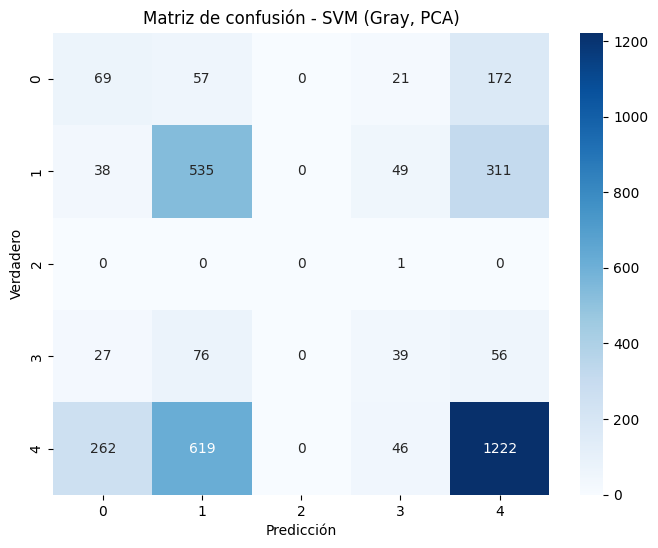

ROC AUC (todas las clases, Gray, PCA): [0.7   0.702 0.95  0.736 0.654]
ROC AUC macro (promedio ignorando NaN, Gray, PCA): 0.7484863601561506


In [11]:
# Definir y entrenar el modelo SVM One-vs-Rest con kernel RBF usando datos con PCA
svm_ovr_gray = OneVsRestClassifier(SVC(kernel='rbf', C=1.0, probability=True, class_weight='balanced', random_state=0))

t0 = time.time()
svm_ovr_gray.fit(Xtr_gray_pca, ytr_gray)
train_time = time.time() - t0
print(f"SVM Gray entrenado en {train_time:.2f}s")

# Predicción y métricas
y_pred_gray = svm_ovr_gray.predict(Xte_gray_pca)
acc_gray = accuracy_score(yte_gray, y_pred_gray)
print(f"Accuracy SVM Gray: {acc_gray:.4f}")
print("Classification report (Gray):")
print(classification_report(yte_gray, y_pred_gray))

# Matriz de confusión (forzar etiquetas para mostrar todas las clases)
from sklearn.utils.multiclass import unique_labels
all_labels = np.arange(5)  # Fuerza 5 clases
cm_gray = confusion_matrix(yte_gray, y_pred_gray, labels=all_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm_gray, cmap='Blues', annot=True, fmt='d', xticklabels=all_labels, yticklabels=all_labels)
plt.title("Matriz de confusión - SVM (Gray, PCA)")
plt.xlabel("Predicción")
plt.ylabel("Verdadero")
plt.show()

# ROC-AUC multiclass (forzar 5 clases)
n_classes = 5
yte_bin_gray = label_binarize(yte_gray, classes=np.arange(n_classes))
try:
    y_score_gray = svm_ovr_gray.predict_proba(Xte_gray_pca)
    auc_per_class_gray = []
    for i in range(n_classes):
        try:
            auc_per_class_gray.append(roc_auc_score(yte_bin_gray[:, i], y_score_gray[:, i]))
        except ValueError:
            auc_per_class_gray.append(np.nan)
    print("ROC AUC (todas las clases, Gray, PCA):", np.round(auc_per_class_gray,3))
    print("ROC AUC macro (promedio ignorando NaN, Gray, PCA):", np.nanmean(auc_per_class_gray))
except Exception as e:
    print(f"ROC AUC no disponible (Gray, PCA): {e}")

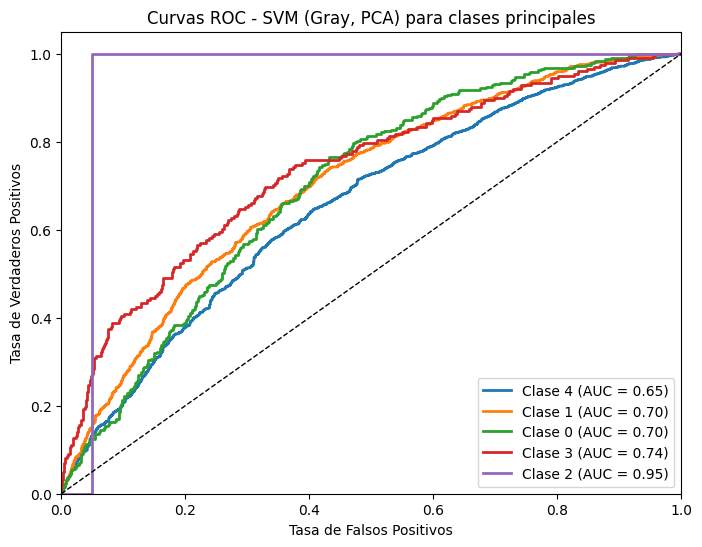

In [12]:
# === Curvas ROC para las clases principales (Gray, PCA) ===
from sklearn.metrics import roc_curve, auc

# Selecciona hasta 5 clases más frecuentes para visualizar
from collections import Counter
clase_frecuentes = [c for c, _ in Counter(yte_gray).most_common(5)]

plt.figure(figsize=(8,6))
for i in clase_frecuentes:
    fpr, tpr, _ = roc_curve(yte_bin_gray[:, i], y_score_gray[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Clase {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC - SVM (Gray, PCA) para clases principales')
plt.legend(loc='lower right')
plt.show()

Fitting 3 folds for each of 12 candidates, totalling 36 fits


/home/debian12/Documentos/mineria-de-datos/MDI/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


[CV] END ..............estimator__C=1, estimator__gamma=0.01; total time= 2.2min
[CV] END ............estimator__C=10, estimator__gamma=0.001; total time= 2.3min
[CV] END ............estimator__C=10, estimator__gamma=0.001; total time= 2.4min
[CV] END ............estimator__C=10, estimator__gamma=0.001; total time= 2.4min
[CV] END .............estimator__C=1, estimator__gamma=0.001; total time= 2.5min
[CV] END .............estimator__C=1, estimator__gamma=0.001; total time= 2.7min
[CV] END .............estimator__C=1, estimator__gamma=0.001; total time= 2.8min
[CV] END ...........estimator__C=0.1, estimator__gamma=0.001; total time= 3.0min
[CV] END .............estimator__C=10, estimator__gamma=0.01; total time= 3.0min
[CV] END ..............estimator__C=1, estimator__gamma=0.01; total time= 3.5min
[CV] END ..............estimator__C=1, estimator__gamma=0.01; total time= 3.5min
[CV] END ............estimator__C=0.1, estimator__gamma=0.01; total time= 3.5min
[CV] END ............estimat

/home/debian12/Documentos/mineria-de-datos/MDI/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/debian12/Documentos/mineria-de-datos/MDI/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/debian12/Documentos/mineria-de-datos/MDI/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

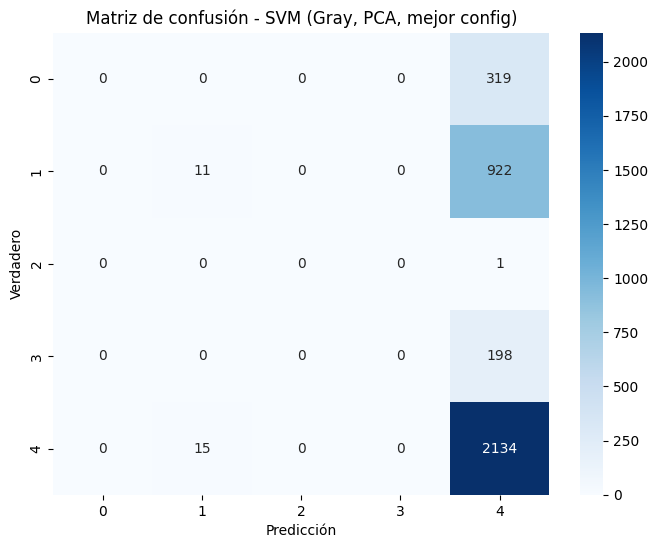

ROC AUC (todas las clases, Gray, PCA, mejor config): [0.632 0.61  0.559 0.669 0.577]
ROC AUC macro (promedio ignorando NaN, Gray, PCA, mejor config): 0.6094792346357341


In [13]:
# --- SVM con RBF, balanceo y ajuste de hiperparámetros con GridSearchCV ---
from sklearn.model_selection import GridSearchCV

# Definir el rango de hiperparámetros
param_grid = {
    'estimator__C': [0.1, 1, 10],
    'estimator__gamma': [0.001, 0.01, 0.1, 1]
}

# SVM base con balanceo y kernel RBF
base_svm = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=0)
svm_ovr = OneVsRestClassifier(base_svm)

grid = GridSearchCV(svm_ovr, param_grid, scoring='accuracy', cv=3, n_jobs=-1, verbose=2)

t0 = time.time()
grid.fit(Xtr_gray_pca, ytr_gray)
train_time = time.time() - t0
print(f"GridSearchCV SVM entrenado en {train_time:.2f}s")
print("Mejores hiperparámetros:", grid.best_params_)

# Predicción y métricas
best_model = grid.best_estimator_
y_pred_gray = best_model.predict(Xte_gray_pca)
acc_gray = accuracy_score(yte_gray, y_pred_gray)
print(f"Accuracy SVM Gray (mejor config): {acc_gray:.4f}")
print("Classification report (Gray, mejor config):")
print(classification_report(yte_gray, y_pred_gray))

# Matriz de confusión
cm_gray = confusion_matrix(yte_gray, y_pred_gray)
plt.figure(figsize=(8,6))
sns.heatmap(cm_gray, cmap='Blues', annot=True, fmt='d')
plt.title("Matriz de confusión - SVM (Gray, PCA, mejor config)")
plt.xlabel("Predicción")
plt.ylabel("Verdadero")
plt.show()

# ROC-AUC multiclass
n_classes = len(np.unique(yte_gray))
yte_bin_gray = label_binarize(yte_gray, classes=np.arange(n_classes))
try:
    y_score_gray = best_model.predict_proba(Xte_gray_pca)
    auc_per_class_gray = []
    for i in range(n_classes):
        try:
            auc_per_class_gray.append(roc_auc_score(yte_bin_gray[:, i], y_score_gray[:, i]))
        except ValueError:
            auc_per_class_gray.append(np.nan)
    print("ROC AUC (todas las clases, Gray, PCA, mejor config):", np.round(auc_per_class_gray,3))
    print("ROC AUC macro (promedio ignorando NaN, Gray, PCA, mejor config):", np.nanmean(auc_per_class_gray))
except Exception as e:
    print(f"ROC AUC no disponible (Gray, PCA, mejor config): {e}")

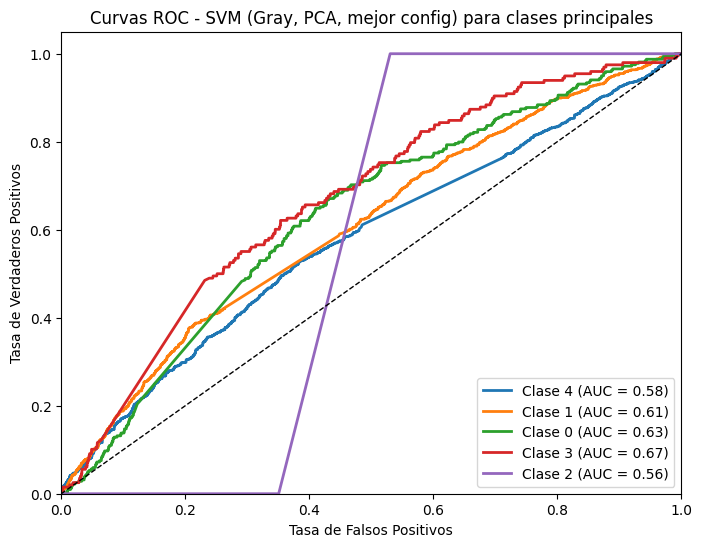

In [14]:
# === Curvas ROC para las clases principales (Gray, PCA, mejor config) ===
from sklearn.metrics import roc_curve, auc

# Selecciona hasta 5 clases más frecuentes para visualizar
from collections import Counter
clase_frecuentes = [c for c, _ in Counter(yte_gray).most_common(5)]

plt.figure(figsize=(8,6))
for i in clase_frecuentes:
    fpr, tpr, _ = roc_curve(yte_bin_gray[:, i], y_score_gray[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Clase {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC - SVM (Gray, PCA, mejor config) para clases principales')
plt.legend(loc='lower right')
plt.show()

In [15]:
# --- SVM con RBF, balanceo y ajuste de hiperparámetros con GridSearchCV para RGB ---

# Reducción de dimensionalidad con PCA para RGB
n_components_rgb = 100
pca_rgb = PCA(n_components=n_components_rgb, random_state=42)
Xtr_rgb_pca = pca_rgb.fit_transform(Xtr_rgb_scaled)
Xte_rgb_pca = pca_rgb.transform(Xte_rgb_scaled)
print(f"RGB PCA: Xtr={Xtr_rgb_pca.shape}, Xte={Xte_rgb_pca.shape}")

# Definir el rango de hiperparámetros
param_grid_rgb = {
    'estimator__C': [0.1, 1, 10],
    'estimator__gamma': [0.001, 0.01, 0.1, 1]
}

# SVM base con balanceo y kernel RBF
base_svm_rgb = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=0)
svm_ovr_rgb = OneVsRestClassifier(base_svm_rgb)

grid_rgb = GridSearchCV(svm_ovr_rgb, param_grid_rgb, scoring='accuracy', cv=3, n_jobs=-1, verbose=2)

t0 = time.time()
grid_rgb.fit(Xtr_rgb_pca, ytr_rgb)
train_time = time.time() - t0
print(f"GridSearchCV SVM RGB entrenado en {train_time:.2f}s")
print("Mejores hiperparámetros RGB:", grid_rgb.best_params_)

# Predicción y métricas
best_model_rgb = grid_rgb.best_estimator_
y_pred_rgb = best_model_rgb.predict(Xte_rgb_pca)
acc_rgb = accuracy_score(yte_rgb, y_pred_rgb)
print(f"Accuracy SVM RGB (mejor config): {acc_rgb:.4f}")
print("Classification report (RGB, mejor config):")
print(classification_report(yte_rgb, y_pred_rgb))

# Matriz de confusión
cm_rgb = confusion_matrix(yte_rgb, y_pred_rgb)
plt.figure(figsize=(8,6))
sns.heatmap(cm_rgb, cmap='Blues', annot=True, fmt='d')
plt.title("Matriz de confusión - SVM (RGB, PCA, mejor config)")
plt.xlabel("Predicción")
plt.ylabel("Verdadero")
plt.show()

# ROC-AUC multiclass
n_classes_rgb = len(np.unique(yte_rgb))
yte_bin_rgb = label_binarize(yte_rgb, classes=np.arange(n_classes_rgb))
try:
    y_score_rgb = best_model_rgb.predict_proba(Xte_rgb_pca)
    auc_per_class_rgb = []
    for i in range(n_classes_rgb):
        try:
            auc_per_class_rgb.append(roc_auc_score(yte_bin_rgb[:, i], y_score_rgb[:, i]))
        except ValueError:
            auc_per_class_rgb.append(np.nan)
    print("ROC AUC (todas las clases, RGB, PCA, mejor config):", np.round(auc_per_class_rgb,3))
    print("ROC AUC macro (promedio ignorando NaN, RGB, PCA, mejor config):", np.nanmean(auc_per_class_rgb))
except Exception as e:
    print(f"ROC AUC no disponible (RGB, PCA, mejor config): {e}")

# === Curvas ROC para las clases principales (RGB, PCA, mejor config) ===
from collections import Counter
clase_frecuentes_rgb = [c for c, _ in Counter(yte_rgb).most_common(5)]

plt.figure(figsize=(8,6))
for i in clase_frecuentes_rgb:
    fpr, tpr, _ = roc_curve(yte_bin_rgb[:, i], y_score_rgb[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Clase {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC - SVM (RGB, PCA, mejor config) para clases principales')
plt.legend(loc='lower right')
plt.show()

RGB PCA: Xtr=(8400, 100), Xte=(3600, 100)
Fitting 3 folds for each of 12 candidates, totalling 36 fits


/home/debian12/Documentos/mineria-de-datos/MDI/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


KeyboardInterrupt: 

In [16]:

# Matriz de confusión
cm_rgb = confusion_matrix(yte_rgb, y_pred_rgb)
plt.figure(figsize=(8,6))
sns.heatmap(cm_rgb, cmap='Blues', annot=True, fmt='d')
plt.title("Matriz de confusión - SVM (RGB, PCA, mejor config)")
plt.xlabel("Predicción")
plt.ylabel("Verdadero")
plt.show()

NameError: name 'y_pred_rgb' is not defined

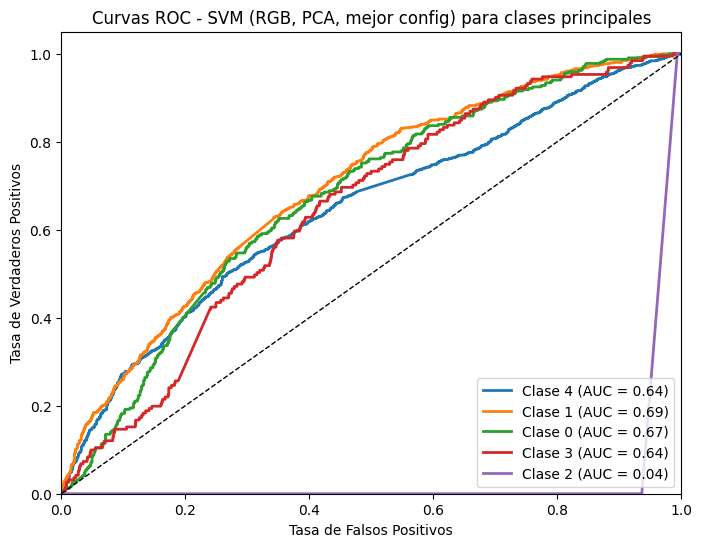

In [ ]:
# === Curvas ROC para las clases principales (RGB, PCA, mejor config) ===
from collections import Counter
clase_frecuentes_rgb = [c for c, _ in Counter(yte_rgb).most_common(5)]

plt.figure(figsize=(8,6))
for i in clase_frecuentes_rgb:
    fpr, tpr, _ = roc_curve(yte_bin_rgb[:, i], y_score_rgb[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Clase {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC - SVM (RGB, PCA, mejor config) para clases principales')
plt.legend(loc='lower right')
plt.show()